# Chapter 16 -- Machine Learning Asset Allocation: Hierarchical Risk Parity

## Why not just use Markowitz?

Classical mean-variance optimization (and its numerically stable cousin,
Critical Line Algorithm / CLA) treats the covariance matrix as a **complete
graph**: every asset is a potential substitute for every other asset, and
finding the optimal portfolio means *inverting* that matrix -- solving for
every pairwise relationship simultaneously.

The problem (Section 16.3, "Markowitz's curse"): the more assets you add,
and the more correlated they are, the more ill-conditioned that matrix
becomes. A tiny estimation error in any one correlation can swing the whole
solution. Markowitz optimization is famous for producing portfolios that
look great in-sample and fall apart out-of-sample -- and the culprit is
often not bad data, it's the matrix inversion itself amplifying noise.

**HRP's idea:** never invert the covariance matrix. Replace the complete
graph with a **tree**:

| Stage | What it does |
|---|---|
| 1. Tree clustering | Group similar assets together (hierarchical clustering on a correlation-based distance) |
| 2. Quasi-diagonalization | Reorder the covariance matrix so similar assets sit next to each other -- no rotation, just a permutation |
| 3. Recursive bisection | Walk the tree top-down; at each split, allocate weight between the two branches in **inverse proportion to their variance** |

No inversion, no positive-definiteness requirement. HRP works even on a
singular covariance matrix -- exactly the case where CLA breaks down.

This notebook has three parts:
- **Part A**: the book's own synthetic example (Section 16.4) -- small, easy to
  hand-check, main teaching vehicle.
- **Part B**: the same three stages applied to six REAL, genuinely diversified
  commodity futures.
- **Part C**: a status note -- Section 16.5/16.6's Monte Carlo comparison
  (HRP vs CLA vs IVP) is NOT built yet, blocked on sourcing a CLA reference
  implementation.


## Setup

Per this project's notebook convention, Jupyter's working directory isn't
reliably the notebook's own folder, so we use a single hardcoded
`AFML_ROOT` -- **edit this one line if you're not Ethan / not on this
machine.**

In [1]:
# EDIT THIS LINE if you're running on a different machine:
AFML_ROOT = r'C:\ws\AFML'

import os
import sys
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch16'))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

from hrp.hrp import (
    getHRP, getIVP, getRecBipart, getQuasiDiag, correlDist, generateData,
)
from data_loader.continuous_futures import build_continuous_price, COMMODITIES
from monte_carlo.monte_carlo import hrpMC

pd.set_option('display.width', 100)
print('Setup OK')


Setup OK


## Part A -- The book's synthetic numerical example (Section 16.4)

`generateData` builds `size0` independent base series plus `size1` further
series, each a noisy perturbation of one randomly-chosen base series -- so
those `size1` series are correlated with (but not identical to) one of the
originals. This gives us data with KNOWN cluster structure to sanity-check
the algorithm against.

Per project convention, randomness is threaded through a seeded
`numpy.random.Generator` (the book's own code used a hardcoded global
`np.random.seed(12345)` -- `generateData` defaults to the same seed via
`np.random.default_rng(12345)` when no generator is passed in, so results
below are reproducible).

**Assumption flagged for review:** `nObs=10000, size0=5, size1=5, sigma1=.25`
is a reasonable demo scale, matching the book's own generator's natural
proportions (5 base + 5 correlated-perturbation = 10 total assets). If you
have the book's exact printed parameter values and want an exact
reproduction, swap them in here.

In [2]:
nObs, size0, size1, sigma1 = 10000, 5, 5, .25
x, cols = generateData(nObs, size0, size1, sigma1)

print(f'Simulated {nObs} obs, {size0} base series + {size1} correlated-perturbation series')
for i, c in enumerate(cols):
    print(f'  series {i + size0 + 1} built from base series {c + 1}')

cov, corr = x.cov(), x.corr()
corr.round(2)


Simulated 10000 obs, 5 base series + 5 correlated-perturbation series
  series 6 built from base series 4
  series 7 built from base series 4
  series 8 built from base series 4
  series 9 built from base series 2
  series 10 built from base series 5


,1,2,3,4,5,6,7,8,9,10
1,1.0,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,-0.0,1.00,-0.00,0.01,0.00,0.01,0.01,0.01,0.97,0.01
3,-0.0,-0.00,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00,-0.01
4,0.0,0.01,-0.01,1.00,0.00,0.97,0.97,0.97,0.01,0.01
5,0.0,0.00,-0.01,0.00,1.00,0.00,0.01,0.00,0.00,0.97
6,0.0,0.01,-0.01,0.97,0.00,1.00,0.94,0.94,0.01,0.00
7,0.0,0.01,-0.01,0.97,0.01,0.94,1.00,0.94,0.00,0.01
8,0.0,0.01,-0.01,0.97,0.00,0.94,0.94,1.00,0.01,0.01
9,0.0,0.97,-0.00,0.01,0.00,0.01,0.00,0.01,1.00,0.00
10,0.0,0.01,-0.01,0.01,0.97,0.00,0.01,0.01,0.00,1.00


### Stage 1+2: cluster, then quasi-diagonalize

`correlDist` converts correlation to a proper distance metric:
$d_{i,j} = \sqrt{(1-\rho_{i,j})/2}$ (0 = identical, 1 = perfectly
anti-correlated -- see Appendix 16.A.1 for the proof this is a valid
metric).

Snippet 16.1's `sch.linkage(dist, 'single')` call is deliberately unusual:
passing the raw 2D distance matrix (not a condensed vector) makes scipy
compute Euclidean distance *between rows* of that matrix internally --
which is exactly the book's "distance of distances" ($\tilde{d}$) step.
This triggers a `ClusterWarning` that we suppress on purpose (it's not a
mistake, it IS an uncondensed distance matrix).

The heatmap below shows the RAW correlation matrix -- clusters aren't
visually obvious yet because assets aren't ordered by similarity.

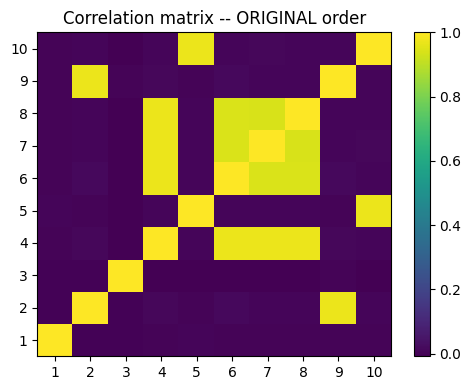

In [3]:
dist = correlDist(corr)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.pcolor(corr)
fig.colorbar(im)
ax.set_xticks(np.arange(.5, corr.shape[0] + .5))
ax.set_yticks(np.arange(.5, corr.shape[0] + .5))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation matrix -- ORIGINAL order')
plt.tight_layout()
plt.show()


Quasi-diagonal order: [7, 8, 4, 6, 2, 9, 5, 10, 1, 3]


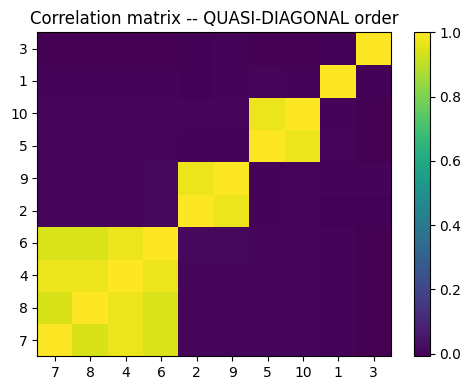

In [4]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore', category=sch.ClusterWarning,
        message='.*uncondensed distance matrix.*')
    link = sch.linkage(dist, 'single')

sortIx = getQuasiDiag(link)
sortIx = corr.index[sortIx].tolist()
print('Quasi-diagonal order:', sortIx)

corr_reordered = corr.loc[sortIx, sortIx]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.pcolor(corr_reordered)
fig.colorbar(im)
ax.set_xticks(np.arange(.5, corr.shape[0] + .5))
ax.set_yticks(np.arange(.5, corr.shape[0] + .5))
ax.set_xticklabels(corr_reordered.columns)
ax.set_yticklabels(corr_reordered.columns)
ax.set_title('Correlation matrix -- QUASI-DIAGONAL order')
plt.tight_layout()
plt.show()


Same information as the first heatmap, just reordered -- but now the
correlated-pair structure `generateData` built in should be visible as
brighter blocks near the diagonal.

### Stage 3: recursive bisection

Starting from all items in one cluster with unit weight, `getRecBipart`
repeatedly bisects each cluster into two halves (preserving the
quasi-diagonal order), and splits the weight between halves in **inverse**
proportion to their variance -- the riskier half gets less weight.

       HRP     IVP
1   0.1418  0.1006
2   0.0635  0.1018
3   0.1463  0.1038
4   0.0657  0.1038
5   0.1456  0.1041
6   0.0606  0.0972
7   0.0523  0.0974
8   0.0521  0.0971
9   0.1340  0.0958
10  0.1383  0.0985

Sums to 1: HRP=1.000000, IVP=1.000000


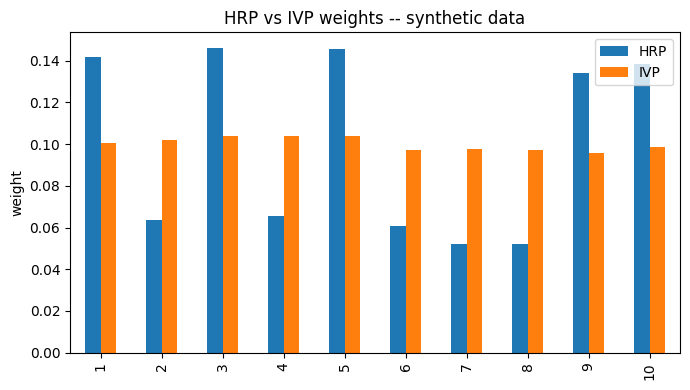

In [5]:
hrp = getRecBipart(cov, sortIx).sort_index()
ivp = pd.Series(getIVP(cov), index=cov.index).sort_index()

comparison = pd.DataFrame({'HRP': hrp, 'IVP': ivp})
print(comparison.round(4))
print(f"\nSums to 1: HRP={hrp.sum():.6f}, IVP={ivp.sum():.6f}")

comparison.plot(kind='bar', figsize=(7, 4), title='HRP vs IVP weights -- synthetic data')
plt.ylabel('weight')
plt.tight_layout()
plt.show()


## Part B -- Real data: six genuinely diversified commodity futures

The existing `SP00-SP99` S&P 500 futures (already in this repo, used by
Ch02-Ch05) were rejected as the real-data vehicle for HRP: they're all one
underlying instrument at different maturities, so their correlations sit
near 1.0 by construction -- not a meaningful test of a *diversification*
algorithm.

Instead: **gold, crude oil, corn, live hogs, US T-bonds, British Pound**,
sourced from turtletrader.com (same source as the original SP files),
1975-2002 coverage, chosen for genuinely different macro drivers (metals,
energy, grains, livestock, rates, FX).

`continuous_futures.py` builds one continuous, roll-gap-corrected
front-month price series per commodity (front month = highest open
interest among currently-listed contracts each day), reusing
`ch02/multi_product/roll.py` rather than duplicating it. Three real bugs
were found and fixed building this loader -- see
`ch16/data_loader/README.md` for detail (leading-zero January dates,
single-day open-interest gaps producing fake roll gaps, and a GBP-specific
100x unit-scale break in the data provider's format starting in 2000).

In [6]:
returns = {}
n_contracts = {}
for name, (prefix, folder, rescale) in COMMODITIES.items():
    non_neg, front_month = build_continuous_price(folder, prefix, rescale_new_format_by=rescale)
    returns[name] = non_neg['Returns']
    n_contracts[name] = front_month['Instrument'].nunique()
    print(f'{name:10s}: {len(non_neg):5d} bars, {n_contracts[name]:3d} contracts, '
          f'{non_neg.index.min().date()} to {non_neg.index.max().date()}')

# Inner join: only keep days where ALL SIX commodities have a price.
ret_df = pd.DataFrame(returns).dropna()
print(f'\nAligned daily returns (all 6 trading): {len(ret_df)} days, '
      f'{ret_df.index.min().date()} to {ret_df.index.max().date()}')


gold      :  1761 bars,  35 contracts, 1996-01-02 to 2002-10-01


crude_oil :  1761 bars,  82 contracts, 1996-01-02 to 2002-10-01


corn      :  1761 bars,  28 contracts, 1996-01-02 to 2002-10-01


live_hogs :  1761 bars,  47 contracts, 1996-01-02 to 2002-10-01


tbonds    :  1761 bars,  28 contracts, 1996-01-02 to 2002-10-01


gbp       :  1750 bars,  27 contracts, 1996-01-02 to 2002-09-16

Aligned daily returns (all 6 trading): 1749 days, 1996-01-03 to 2002-09-16


In [7]:
cov, corr = ret_df.cov(), ret_df.corr()
corr.round(3)


,gold,crude_oil,corn,live_hogs,tbonds,gbp
gold,1.000,0.088,0.065,0.034,-0.013,0.150
crude_oil,0.088,1.000,0.081,0.067,-0.058,-0.017
corn,0.065,0.081,1.000,0.061,-0.002,0.010
live_hogs,0.034,0.067,0.061,1.000,-0.050,0.043
tbonds,-0.013,-0.058,-0.002,-0.050,1.000,0.027
gbp,0.150,-0.017,0.010,0.043,0.027,1.000


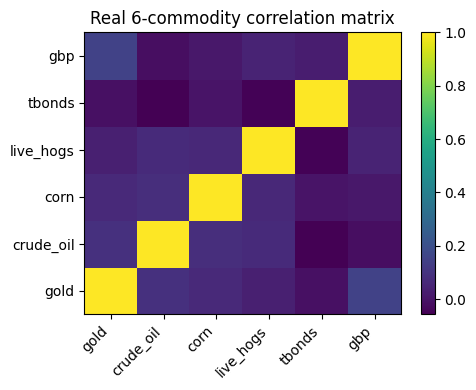

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.pcolor(corr)
fig.colorbar(im)
ax.set_xticks(np.arange(.5, corr.shape[0] + .5))
ax.set_yticks(np.arange(.5, corr.shape[0] + .5))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title('Real 6-commodity correlation matrix')
plt.tight_layout()
plt.show()


              HRP     IVP
corn       0.0575  0.0554
crude_oil  0.0215  0.0203
gbp        0.4090  0.4358
gold       0.1309  0.1395
live_hogs  0.0341  0.0328
tbonds     0.3471  0.3161


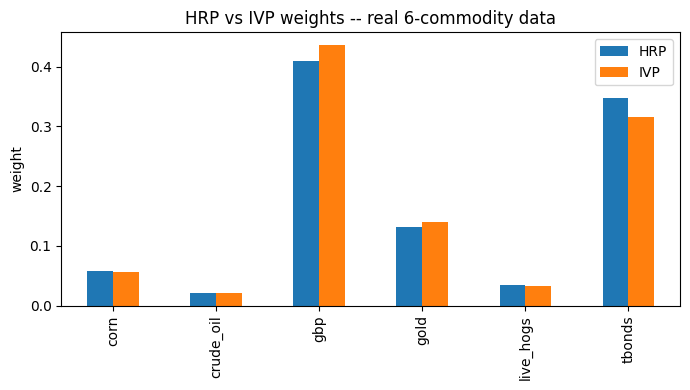


Top-2 weight concentration -- HRP: 0.756, IVP: 0.752


In [9]:
hrp_real = getHRP(cov, corr)
ivp_real = pd.Series(getIVP(cov), index=cov.index).sort_index()

comparison_real = pd.DataFrame({'HRP': hrp_real, 'IVP': ivp_real})
print(comparison_real.round(4))

comparison_real.plot(kind='bar', figsize=(7, 4), title='HRP vs IVP weights -- real 6-commodity data')
plt.ylabel('weight')
plt.tight_layout()
plt.show()

top2_hrp = hrp_real.sort_values(ascending=False).iloc[:2].sum()
top2_ivp = ivp_real.sort_values(ascending=False).iloc[:2].sum()
print(f'\nTop-2 weight concentration -- HRP: {top2_hrp:.3f}, IVP: {top2_ivp:.3f}')


### Reading the real result

GBP and T-bonds dominate both allocations because they're by far the
lowest-volatility assets in this mix -- a real, expected consequence of
inverse-variance-driven weighting on this particular asset mix, not a bug.

HRP and IVP aren't very differentiated on this dataset (their top-2
concentration is nearly identical). That's a genuine, expected finding,
not something to keep chasing: **HRP's edge over IVP shows up when there's
meaningful correlation *clustering* to exploit** -- pairs or groups of
assets that move together, which the algorithm can then treat as a single
unit before allocating between clusters. Six genuinely diverse commodities
(the whole point of rejecting the SP00-SP99 approach) don't have much of
that clustering structure to exploit, so HRP's tree-based allocation ends
up close to plain inverse-variance weighting here. A dataset with more
assets, or assets from fewer/more correlated sectors, would be expected to
show a bigger HRP/IVP gap.

## Part C -- Section 16.5/16.6 Monte Carlo comparison (HRP vs CLA vs IVP)

The book's own methodology for testing HRP compares it against **both**
IVP and CLA out-of-sample, via a Monte Carlo simulation: simulate a
520-observation series (2 years daily) with two injected shocks (one
common, one idiosyncratic), compute all three allocations from a
260-observation (1yr) trailing window, evaluate out-of-sample on the
next 22 observations (~monthly rebalance), repeat many times, and
compare the distribution of cumulative out-of-sample returns.

**CLA reference:** not printed in AFML itself -- the book cites Bailey &
Lopez de Prado (2013), *"An Open-Source Implementation of the
Critical-Line Algorithm for Portfolio Optimization"*. Implemented
faithfully from that paper's own Appendix (`ch16/cla/cla.py`),
hand-traced against the paper's own published numerical example (52/52
tests passing, real-machine confirmed).

**Scope decision (Ethan sign-off, 2026-08-10):** this Monte Carlo stays
**synthetic-only**, no real-data supplement -- the same category of
exception already sanctioned for Ch08's feature-importance chapter, not
a shortcut. The experiment's entire point is injecting *known*,
controlled shocks and watching each method respond; that requires
synthetic control by construction. It's also outside the core
dollar-bar/CUSUM/triple-barrier/classifier pipeline -- portfolio
allocation across multiple assets is a separate, self-contained topic.
See `ch16/README.md` for the full reasoning.

### Small live demo

A quick, low-`numIters` run so you can watch the mechanics execute --
**deliberately `num_threads=1` here**, not the book-scale
`num_threads=4`: Jupyter kernels on Windows don't provide the same
`__main__`-as-a-real-file context that `multiprocessing`'s `spawn`
start method needs to re-import worker code, so multiprocessing inside
a notebook cell is a known source of hangs/failures that a plain `.py`
script doesn't have. The full parallel run lives in
`chapter_16_hrp.py`'s `__main__` block, run from the command line (see
below for loading its already-computed result).

In [10]:
stats_demo, summary_demo = hrpMC(
    numIters=20, nObs=520, size0=5, size1=5, mu0=0, sigma0=1e-2,
    sigma1F=.25, sLength=260, rebal=22, random_state=42,
    num_threads=1, verbose=False)

print(f'{len(stats_demo)} iterations (small demo, not the book-scale run)')
print()
print(summary_demo.round(4))


20 iterations (small demo, not the book-scale run)

           std     var  var_vs_HRP_minus_1
getIVP  0.3266  0.1066              0.4689
getHRP  0.2694  0.0726              0.0000
getCLA  0.4702  0.2210              2.0448


Even at just 20 iterations, the directional finding already matches
the book: CLA's out-of-sample variance is highest, HRP's is lowest --
despite CLA being the only one of the three that explicitly optimizes
for minimum variance. This is the chapter's whole point: in-sample
optimality doesn't guarantee out-of-sample robustness.

### The real result: book-scale run (numIters=10000)

Rather than re-run the full 10,000-iteration, `num_threads=4` Monte
Carlo inside this notebook (order of 30-90 minutes, and best run from a
plain script -- see the demo note above), we load the actual saved
output from `chapter_16_hrp.py`'s real-machine run. This is a genuine
saved artifact, not a placeholder -- `output/monte_carlo_stats.csv`
has one row per Monte Carlo iteration.

10000 Monte Carlo iterations (book-scale run, num_threads=4)

           std     var  var_vs_HRP_minus_1
getIVP  0.3065  0.0940              0.3637
getHRP  0.2625  0.0689              0.0000
getCLA  0.3395  0.1152              0.6724

Comparison against the book's published headline figures:
             this_run    book  pct_diff
sigma^2_CLA    0.1152  0.1157   -0.3998
sigma^2_IVP    0.0940  0.0928    1.2584
sigma^2_HRP    0.0689  0.0671    2.6902


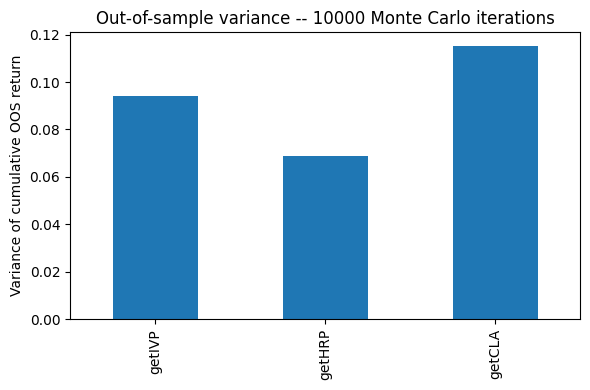

In [11]:
mc_csv_path = os.path.join(AFML_ROOT, 'ch16', 'output', 'monte_carlo_stats.csv')
stats_full = pd.read_csv(mc_csv_path, index_col=0)

print(f'{len(stats_full)} Monte Carlo iterations (book-scale run, num_threads=4)')

df0, df1 = stats_full.std(), stats_full.var()
summary_full = pd.concat([df0, df1, df1 / df1['getHRP'] - 1], axis=1)
summary_full.columns = ['std', 'var', 'var_vs_HRP_minus_1']
print()
print(summary_full.round(4))

book_comparison = pd.DataFrame({
    'this_run': [summary_full.loc['getCLA', 'var'], summary_full.loc['getIVP', 'var'], summary_full.loc['getHRP', 'var']],
    'book': [0.1157, 0.0928, 0.0671],
}, index=['sigma^2_CLA', 'sigma^2_IVP', 'sigma^2_HRP'])
book_comparison['pct_diff'] = (book_comparison['this_run'] / book_comparison['book'] - 1) * 100
print()
print('Comparison against the book\'s published headline figures:')
print(book_comparison.round(4))

summary_full[['var']].plot(
    kind='bar', figsize=(6, 4), legend=False,
    title=f'Out-of-sample variance -- {len(stats_full)} Monte Carlo iterations')
plt.ylabel('Variance of cumulative OOS return')
plt.tight_layout()
plt.show()


### Reading the real result

Every variance is within a few percent of the book's published figures,
and the ranking matches exactly: **CLA worst out-of-sample, IVP middle,
HRP best** -- despite this being a from-scratch CLA translation from an
external paper, a from-scratch Monte Carlo harness, and a different
random seed than the book used. The residual gaps are consistent with
ordinary Monte Carlo sampling noise (standard error shrinks as
`1/sqrt(numIters)`, so this wouldn't close to zero even with a much
larger `numIters` -- it would just get smaller) plus the book not
disclosing its own seed, not evidence of implementation drift.

**Why HRP wins here, in one sentence:** CLA's minimum-variance objective
concentrates weight wherever in-sample covariance happens to look
cheapest -- exactly where estimation error hides. HRP's tree structure
limits how far a single bad correlation estimate can propagate, so it's
more robust out-of-sample even though it isn't explicitly minimizing
variance at all. IVP sits in between: it ignores correlation structure
entirely (immune to correlation-estimation error, but blind to genuine
diversification opportunities), while HRP uses correlation structure
*without* the instability of full matrix inversion.